In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from statsmodels.multivariate.cancorr import CanCorr


In [11]:
df = pd.read_csv("D:\\University\\4000L 1st sem\\DSC4033 Multivariate II\\Mini_project\\Data\\archive (5)\\train.csv")

df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,03-01-2015 01:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,03-01-2015 02:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,03-01-2015 03:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,03-01-2015 04:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,03-01-2015 05:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


### Test the datetime format

In [12]:
df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

print(df["datetime"].isna().sum())
print(df["datetime"].dtype)
df.head()

0
datetime64[ns]


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


No missing values. That means the format is correct for all records.


In [13]:
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek   # Monday=0 ... Sunday=6
df["month"] = df["datetime"].dt.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)

df.head()


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,school,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,...,0,1,5,1,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,...,0,2,5,1,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,...,0,3,5,1,0.707107,0.707107,-0.974928,-0.222521,0.0,1.0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,...,0,4,5,1,0.866025,0.500000,-0.974928,-0.222521,0.0,1.0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,...,0,5,5,1,0.965926,0.258819,-0.974928,-0.222521,0.0,1.0


### Define the 2 variable sets


In [14]:
# X block = weather variables
x_cols = [
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav"
]

# Y block = demand + calendar/time variables
y_cols = [
    "nat_demand",
    "holiday",
    "school",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos"
]

# Keep only needed columns
data = df[x_cols + y_cols].copy()

# Convert to numeric just in case
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")


### REMOVE CONSTANT COLUMNS

In [15]:
constant_cols = [c for c in data.columns if data[c].nunique() <= 1]
if constant_cols:
    raise ValueError(
        f"These columns have zero variance: {constant_cols}\n"
        "Remove them before running CCA."
    )

### Split into X and Y

In [16]:
X = data[x_cols].to_numpy()
Y = data[y_cols].to_numpy()

n_samples = X.shape[0]
p = X.shape[1]
q = Y.shape[1]

n_components = min(n_samples, p, q)

print(f"Rows used: {n_samples}")
print(f"X variables: {p}")
print(f"Y variables: {q}")
print(f"Canonical functions/components: {n_components}")

Rows used: 43775
X variables: 12
Y variables: 9
Canonical functions/components: 9


### STANDARDIZE

In [17]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

Xz = x_scaler.fit_transform(X)
Yz = y_scaler.fit_transform(Y)

### FIT CCA

In [19]:
cca = CCA(n_components=n_components, scale=False, max_iter=2000)
X_scores, Y_scores = cca.fit_transform(Xz, Yz)

# Canonical correlations
canonical_corrs = [
    np.corrcoef(X_scores[:, i], Y_scores[:, i])[0, 1]
    for i in range(n_components)
]

### EXTRACT WEIGHTS

In [20]:
x_weights = pd.DataFrame(
    cca.x_weights_,
    index=x_cols,
    columns=[f"CV{i+1}" for i in range(n_components)]
)

y_weights = pd.DataFrame(
    cca.y_weights_,
    index=y_cols,
    columns=[f"CV{i+1}" for i in range(n_components)]
)

### LOADINGS (structure coefficients)

In [21]:
x_loadings = pd.DataFrame(
    [
        [np.corrcoef(Xz[:, j], X_scores[:, i])[0, 1] for i in range(n_components)]
        for j in range(Xz.shape[1])
    ],
    index=x_cols,
    columns=[f"CV{i+1}" for i in range(n_components)]
)

y_loadings = pd.DataFrame(
    [
        [np.corrcoef(Yz[:, j], Y_scores[:, i])[0, 1] for i in range(n_components)]
        for j in range(Yz.shape[1])
    ],
    index=y_cols,
    columns=[f"CV{i+1}" for i in range(n_components)]
)

### CROSS-LOADINGS

In [22]:
x_cross_loadings = pd.DataFrame(
    [
        [np.corrcoef(Xz[:, j], Y_scores[:, i])[0, 1] for i in range(n_components)]
        for j in range(Xz.shape[1])
    ],
    index=x_cols,
    columns=[f"CV{i+1}" for i in range(n_components)]
)

y_cross_loadings = pd.DataFrame(
    [
        [np.corrcoef(Yz[:, j], X_scores[:, i])[0, 1] for i in range(n_components)]
        for j in range(Yz.shape[1])
    ],
    index=y_cols,
    columns=[f"CV{i+1}" for i in range(n_components)]
)

### SCORES

In [23]:
x_scores_df = pd.DataFrame(
    X_scores,
    columns=[f"X_CV{i+1}" for i in range(n_components)]
)

y_scores_df = pd.DataFrame(
    Y_scores,
    columns=[f"Y_CV{i+1}" for i in range(n_components)]
)

### SUMMARY TABLE

In [25]:
cca_summary = pd.DataFrame({
    "Canonical Function": [f"CV{i+1}" for i in range(n_components)],
    "Canonical Correlation": canonical_corrs,
    "Squared Canonical Correlation": np.square(canonical_corrs)
})
cca_summary

,Canonical Function,Canonical Correlation,Squared Canonical Correlation
0,CV1,0.889638,0.791455
1,CV2,0.788247,0.621334
2,CV3,0.477131,0.227654
3,CV4,0.362245,0.131221
4,CV5,0.287875,0.082872
5,CV6,0.143029,0.020457
6,CV7,0.065963,0.004351
7,CV8,0.033320,0.001110
8,CV9,0.027738,0.000769


### SIGNIFICANCE TESTS (statsmodels)

In [26]:
try:
    sm_cca = CanCorr(endog=Yz, exog=Xz)
    sm_test = sm_cca.corr_test()

    significance_table = sm_test.stats.copy()
    multivariate_table = sm_test.stats_mv.copy()
except Exception as e:
    significance_table = pd.DataFrame({"Error": [str(e)]})
    multivariate_table = pd.DataFrame({"Error": [str(e)]})


### PRINT RESULTS

In [27]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

print("\n==============================")
print("CANONICAL CORRELATIONS")
print("==============================")
print(cca_summary.round(4))

print("\n==============================")
print("X WEIGHTS")
print("==============================")
print(x_weights.round(4))

print("\n==============================")
print("Y WEIGHTS")
print("==============================")
print(y_weights.round(4))

print("\n==============================")
print("X LOADINGS")
print("==============================")
print(x_loadings.round(4))

print("\n==============================")
print("Y LOADINGS")
print("==============================")
print(y_loadings.round(4))

print("\n==============================")
print("X CROSS-LOADINGS")
print("==============================")
print(x_cross_loadings.round(4))

print("\n==============================")
print("Y CROSS-LOADINGS")
print("==============================")
print(y_cross_loadings.round(4))

print("\n==============================")
print("SIGNIFICANCE TESTS")
print("==============================")
print(significance_table)

print("\n==============================")
print("MULTIVARIATE TESTS")
print("==============================")
print(multivariate_table)


CANONICAL CORRELATIONS
  Canonical Function  Canonical Correlation  Squared Canonical Correlation
0                CV1                 0.8896                         0.7915
1                CV2                 0.7882                         0.6213
2                CV3                 0.4771                         0.2277
3                CV4                 0.3622                         0.1312
4                CV5                 0.2879                         0.0829
5                CV6                 0.1430                         0.0205
6                CV7                 0.0660                         0.0044
7                CV8                 0.0333                         0.0011
8                CV9                 0.0277                         0.0008

X WEIGHTS
             CV1     CV2     CV3     CV4     CV5     CV6     CV7     CV8     CV9
T2M_toc   0.5832 -0.1929  0.2848 -0.0667 -0.2828  0.2286  0.5102  0.0893 -0.2891
QV2M_toc -0.4166 -0.5580 -0.0692 -0.2204  0.2408  0.4

### GRAPH 1: CANONICAL CORRELATIONS

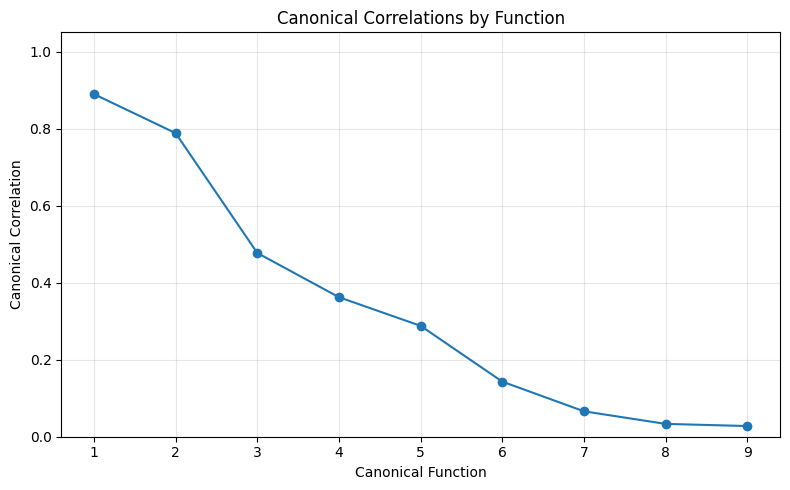

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), canonical_corrs, marker="o")
plt.title("Canonical Correlations by Function")
plt.xlabel("Canonical Function")
plt.ylabel("Canonical Correlation")
plt.xticks(range(1, n_components + 1))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cca_canonical_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

### GRAPH 2: SQUARED CANONICAL CORRELATIONS

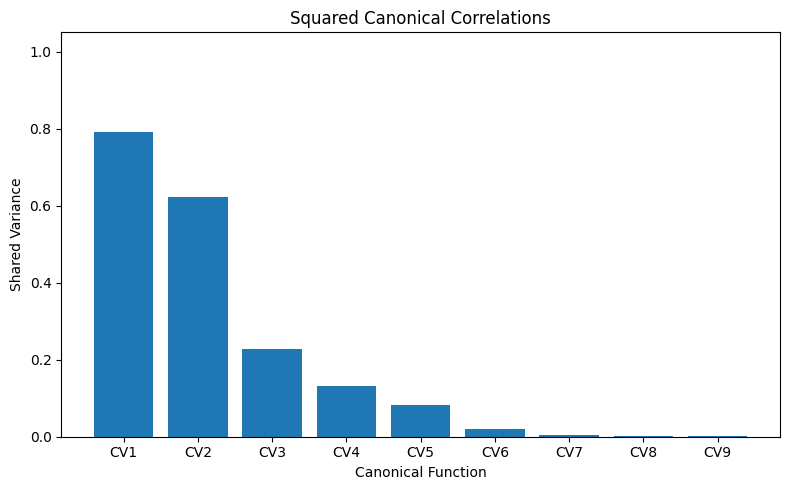

In [36]:
plt.figure(figsize=(8, 5))
plt.bar([f"CV{i+1}" for i in range(n_components)], np.square(canonical_corrs))
plt.title("Squared Canonical Correlations")
plt.xlabel("Canonical Function")
plt.ylabel("Shared Variance")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("cca_squared_canonical_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

### GRAPH 3: CV1 CANONICAL SCORES SCATTER

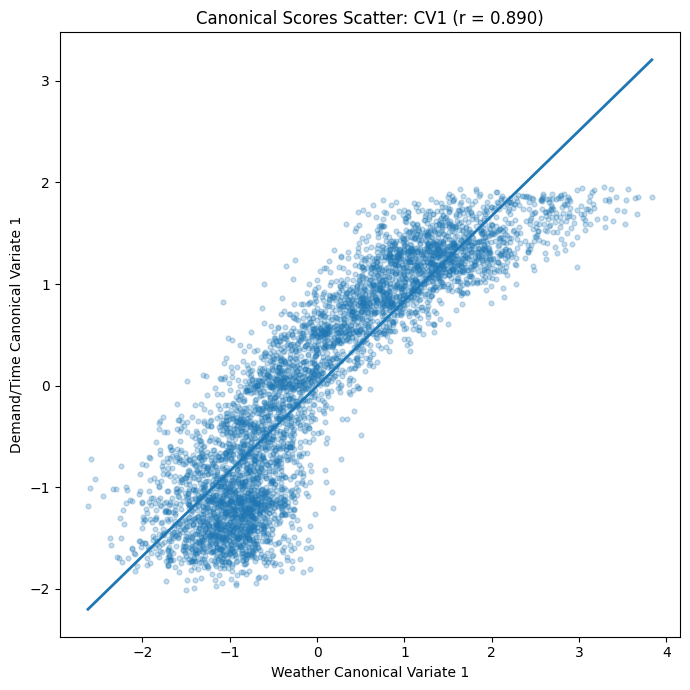

In [37]:
plot_df = pd.DataFrame({
    "X_CV1": X_scores[:, 0],
    "Y_CV1": Y_scores[:, 0]
})

# If dataset is large, sample points for cleaner graph
if len(plot_df) > 5000:
    plot_df = plot_df.sample(5000, random_state=42)

plt.figure(figsize=(7, 7))
plt.scatter(plot_df["X_CV1"], plot_df["Y_CV1"], alpha=0.25, s=12)
plt.title(f"Canonical Scores Scatter: CV1 (r = {canonical_corrs[0]:.3f})")
plt.xlabel("Weather Canonical Variate 1")
plt.ylabel("Demand/Time Canonical Variate 1")

# regression line
coef = np.polyfit(plot_df["X_CV1"], plot_df["Y_CV1"], 1)
x_line = np.linspace(plot_df["X_CV1"].min(), plot_df["X_CV1"].max(), 100)
y_line = coef[0] * x_line + coef[1]
plt.plot(x_line, y_line, linewidth=2)

plt.tight_layout()
plt.savefig("cca_cv1_scores_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
def save_loadings_plot(series, title):
    series = series.sort_values(key=lambda s: s.abs())
    plt.figure(figsize=(9, 6))
    plt.barh(series.index, series.values)
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Loading")
    plt.ylabel("Variable")
    plt.tight_layout()
    #plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

### GRAPH 4: X LOADINGS ON CV1

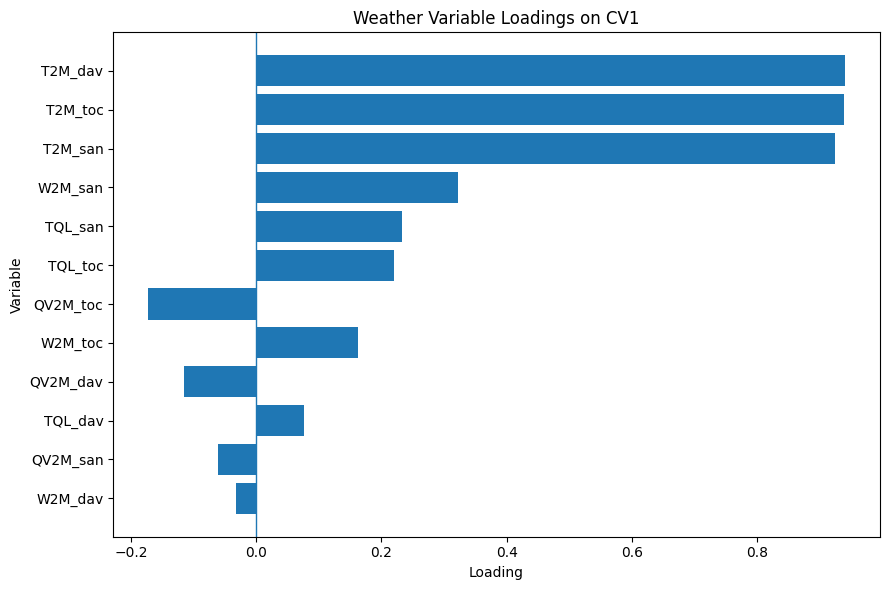

In [43]:
save_loadings_plot(
    x_loadings["CV1"],
    "Weather Variable Loadings on CV1"
)

### GRAPH 5: Y LOADINGS ON CV1

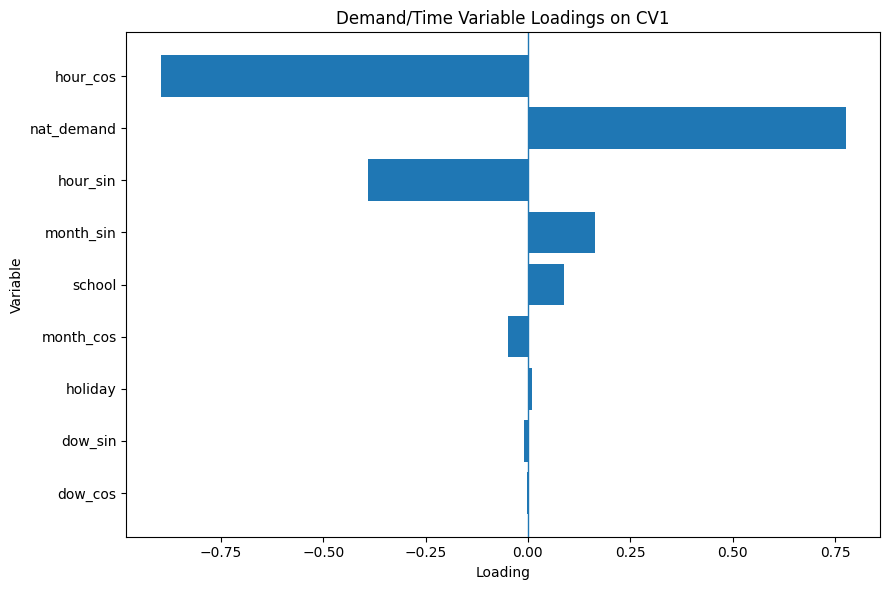

In [44]:
save_loadings_plot(
    y_loadings["CV1"],
    "Demand/Time Variable Loadings on CV1")

### GRAPH 6: X LOADINGS ON CV2

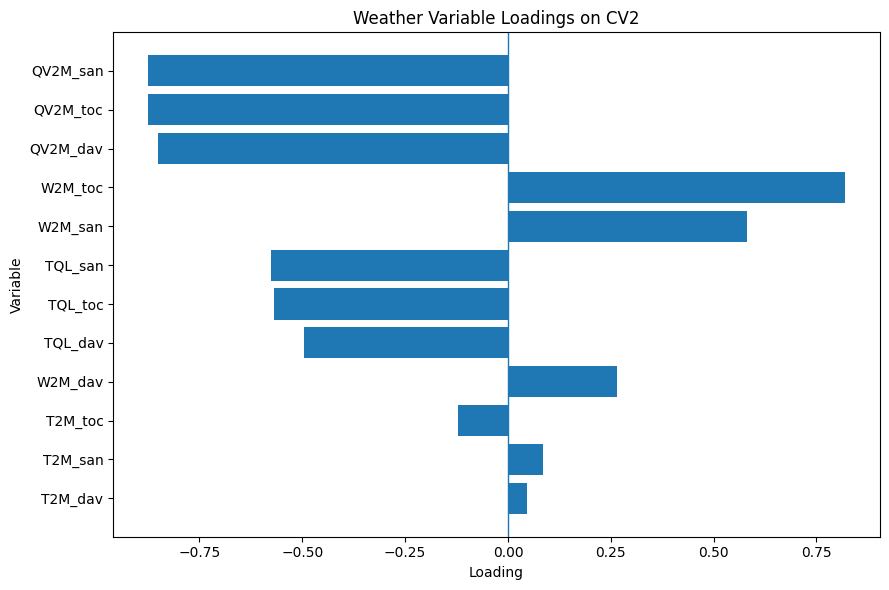

In [45]:
save_loadings_plot(
    x_loadings["CV2"],
    "Weather Variable Loadings on CV2")

### GRAPH 7: Y LOADINGS ON CV2

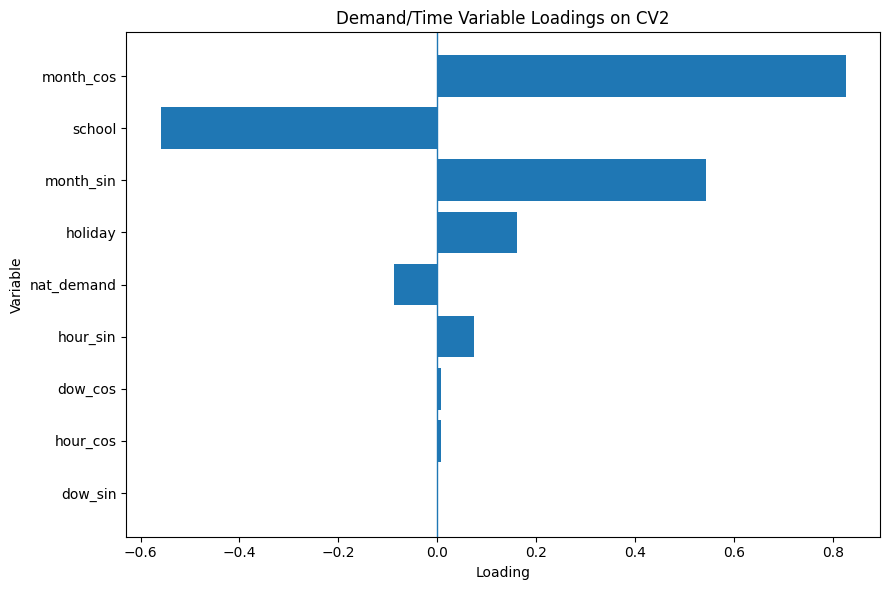

In [46]:
save_loadings_plot(
    y_loadings["CV2"],
    "Demand/Time Variable Loadings on CV2")